In [2]:
import pandas as pd
 
df = pd.read_csv('Meteo data.csv', sep=';', decimal='.')
 
# A list containing the starting days for the months
months_change = [0, 31, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
# A list containing the names of the months
months_names = ['January', 'February', 'March', 'April', 'May', 'June',
                'July', 'August', 'September', 'October', 'November', 'December']
# Dataset containing 12 values: average for monthly measurements
df_month_avg = df.groupby('Month')[[
        'Average daily temperature', 'Average daily relative humidity',
        'Average daily wind speed [m/s]', 'Average daily cloud cover [oktas]'
]].mean()
 
df_month_avg.columns = [
        'Average temperature', 'Average relative humidity',
        'Average wind speed [m/s]', 'Average total cloud cover [oktas]'
]

Task 1:
Generate a bar plot of average temperatures in 2020.

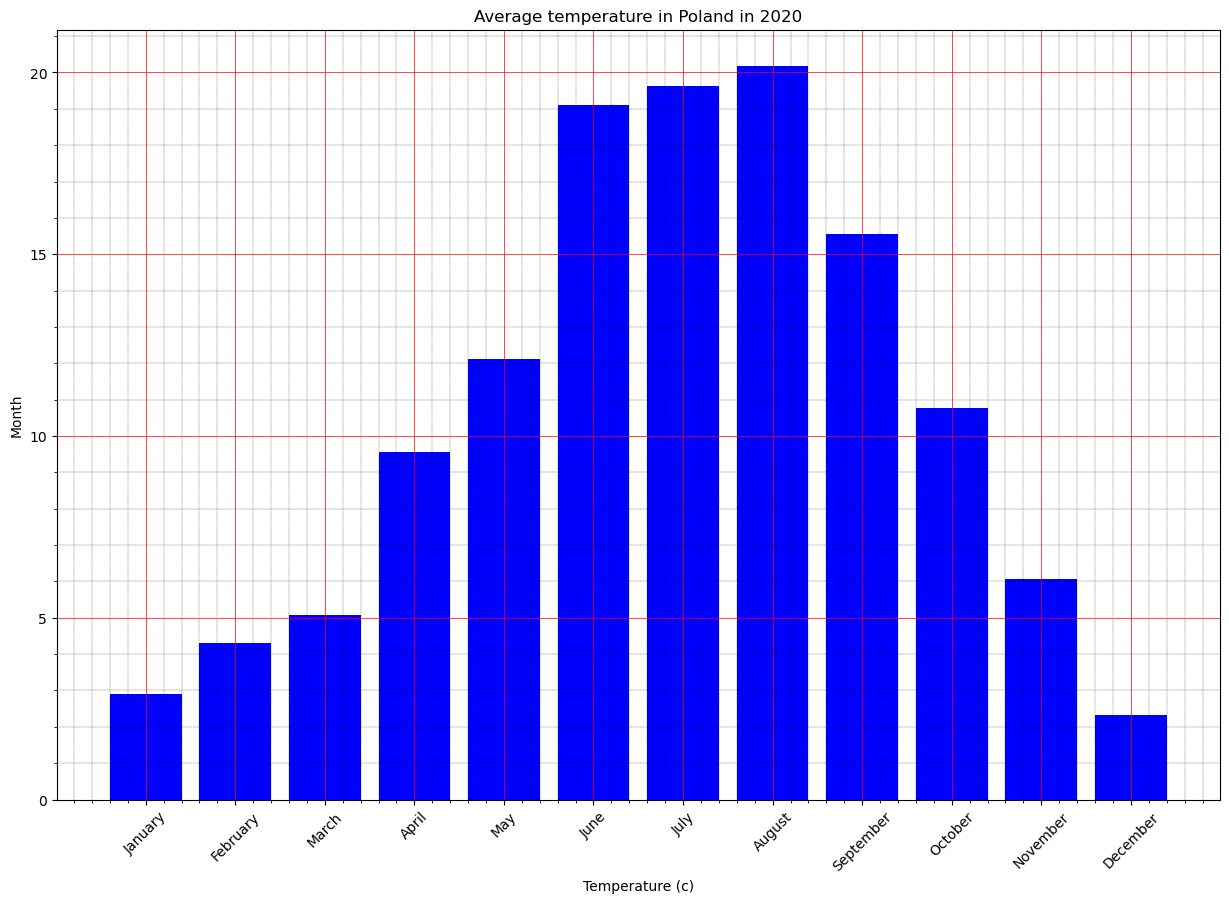

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,10))
 
plt.bar(range(1, 13), df_month_avg['Average temperature'], color='blue')
 
plt.xticks(range(1, 13), months_names, rotation=45)
plt.yticks(range(0, 25, 5))
 
plt.title('Average temperature in Poland in 2020')
 
plt.ylabel('Month')
plt.xlabel('Temperature (c)')
 
plt.minorticks_on()
 
plt.grid(which='major', linestyle='-', linewidth='0.5', color='red')
plt.grid(which='minor', linestyle='--', linewidth='0.2', color='black')

Task 2:
Prepare a cumulative bar plot that will visualize the number of nice and bad-weather days in each month. By nice days, we mean those with the cloud cover less than or equal to 4 oktas.

In [4]:
df['Average daily cloud cover [oktas]'] <= 4

0      False
1      False
2      False
3      False
4       True
       ...  
361     True
362    False
363    False
364    False
365    False
Name: Average daily cloud cover [oktas], Length: 366, dtype: bool

In [5]:
df_nice_days = df.loc[df['Average daily cloud cover [oktas]'] <= 4]
df_bad_days = df.loc[df['Average daily cloud cover [oktas]'] > 4]
 
s_nice_days_per_month = df_nice_days.groupby('Month').size()
s_bad_days_per_month = df_bad_days.groupby('Month').size()

In [6]:
s_nice_days_per_month

Month
1      5
2      7
3     15
4     23
5     13
6     12
7     13
8     19
9     16
10     8
11     4
12     6
dtype: int64

In [7]:
df_nice_days

,Station code,Station name,Year,Month,Day,Average daily temperature,Average daily relative humidity,Average daily wind speed [m/s],Average daily cloud cover [oktas]
4,252200150,WARSZAWA-BIELANY,2020,1,5,0.7,79.5,3.3,0.7
13,252200150,WARSZAWA-BIELANY,2020,1,14,3.8,79.5,2.7,3.0
14,252200150,WARSZAWA-BIELANY,2020,1,15,5.4,61.8,2.7,1.3
15,252200150,WARSZAWA-BIELANY,2020,1,16,5.1,75.8,3.0,1.0
20,252200150,WARSZAWA-BIELANY,2020,1,21,2.1,81.0,5.3,3.3
...,...,...,...,...,...,...,...,...,...
338,252200150,WARSZAWA-BIELANY,2020,12,4,2.7,82.3,5.0,3.7
339,252200150,WARSZAWA-BIELANY,2020,12,5,7.4,76.5,5.0,1.7
341,252200150,WARSZAWA-BIELANY,2020,12,7,1.2,80.5,7.0,3.7
357,252200150,WARSZAWA-BIELANY,2020,12,23,4.8,87.0,2.3,3.7


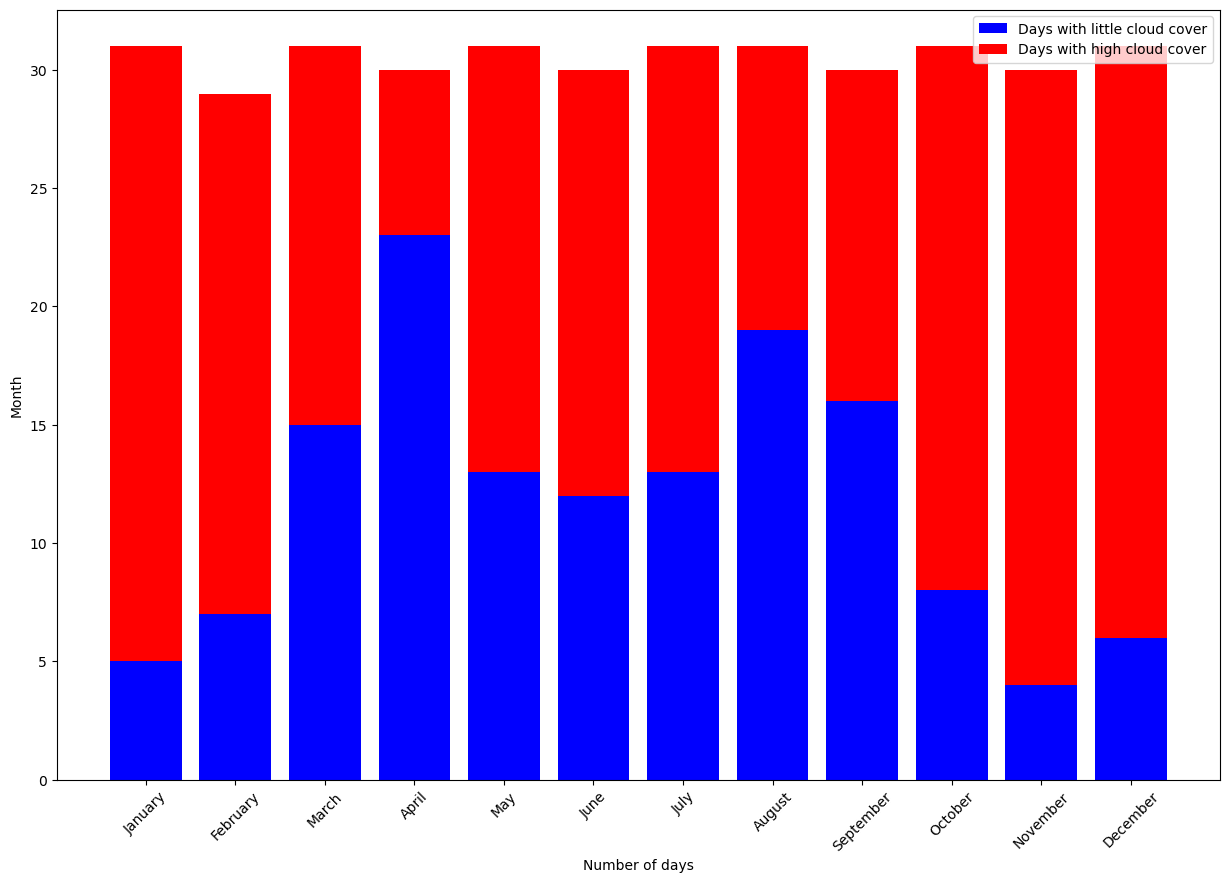

In [8]:
plt.figure(figsize=(15,10))
 
plt.bar(range(1, 13), s_nice_days_per_month, color='blue',
        label='Days with little cloud cover')
plt.bar(range(1, 13), s_bad_days_per_month, color='red',
        bottom=s_nice_days_per_month, label='Days with high cloud cover')
 
plt.xticks(range(1, 13), months_names, rotation=45)
 
plt.ylabel('Month')
plt.xlabel('Number of days')
 
plt.legend()

Task 3:
Generate Histogram of temperature distribution in Poland in 2020

Text(0.5, 1.0, 'Histogram of temperature distribution in Poland in 2020')

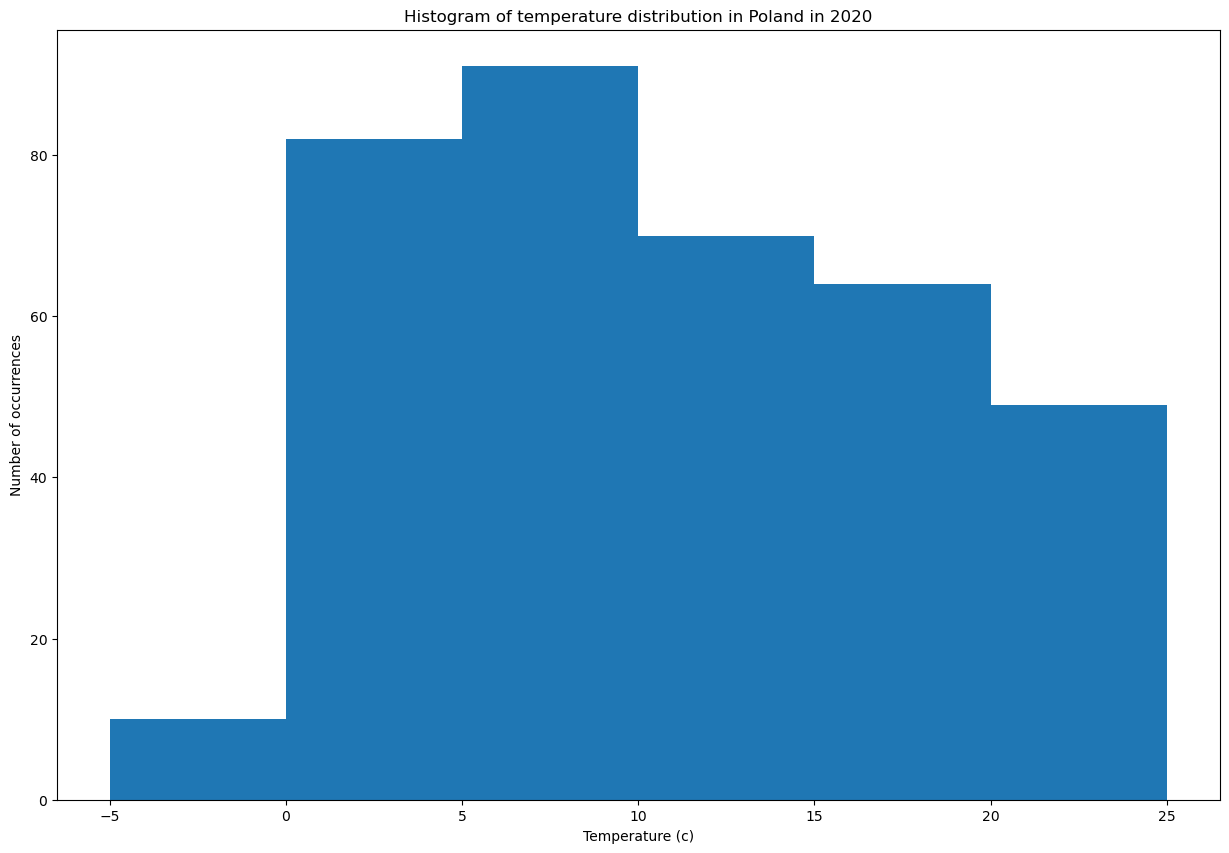

In [9]:
plt.figure(figsize=(15,10))
 
x = plt.hist(df['Average daily temperature'],bins=range(-5,30,5))
plt.ylabel('Number of occurrences')
plt.xlabel('Temperature (c)')
plt.title('Histogram of temperature distribution in Poland in 2020')

In [10]:
bins = [0, 20, 40, 60, 80, 100]
# Funkcija cut deli numeričke podatke na intervale (binove).
s = pd.cut(df['Average daily relative humidity'], bins=bins).value_counts()
s

Average daily relative humidity
(80, 100]    155
(60, 80]     138
(40, 60]      62
(20, 40]      11
(0, 20]        0
Name: count, dtype: int64

Task 4: Generate Pie chart that show what the distribution of humidity looks like over the year

"s — niz vrednosti (broj elemenata u svakoj kategoriji).\nlabels — tekst koji će stajati uz svaki sektor.\nexplode=[0, 0.1, 0, 0, 0] — drugi sektor je izdvojen za 10% poluprečnika.\nautopct='%1.1f%%' — prikazuje procente sa jednom decimalom:\n%% služi da se ispiše znak %.\nshadow=True — dodaje senku grafikonu."

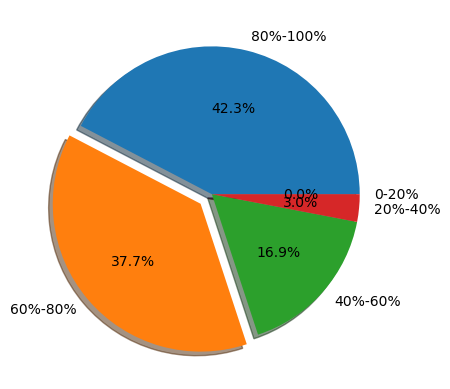

In [11]:
plt.pie(s, labels=['80%-100%', '60%-80%', '40%-60%', '20%-40%', '0-20%'],
explode = [0, 0.1, 0, 0, 0], autopct='%1.1f%%', shadow=True)
'''s — niz vrednosti (broj elemenata u svakoj kategoriji).
labels — tekst koji će stajati uz svaki sektor.
explode=[0, 0.1, 0, 0, 0] — drugi sektor je izdvojen za 10% poluprečnika.
autopct='%1.1f%%' — prikazuje procente sa jednom decimalom:
%% služi da se ispiše znak %.
shadow=True — dodaje senku grafikonu.'''

Task 5: Generate Scatter plot that shows average daly temperatures in Poland in 2020


Text(0.5, 1.0, 'Temperature in Poland in 2020')

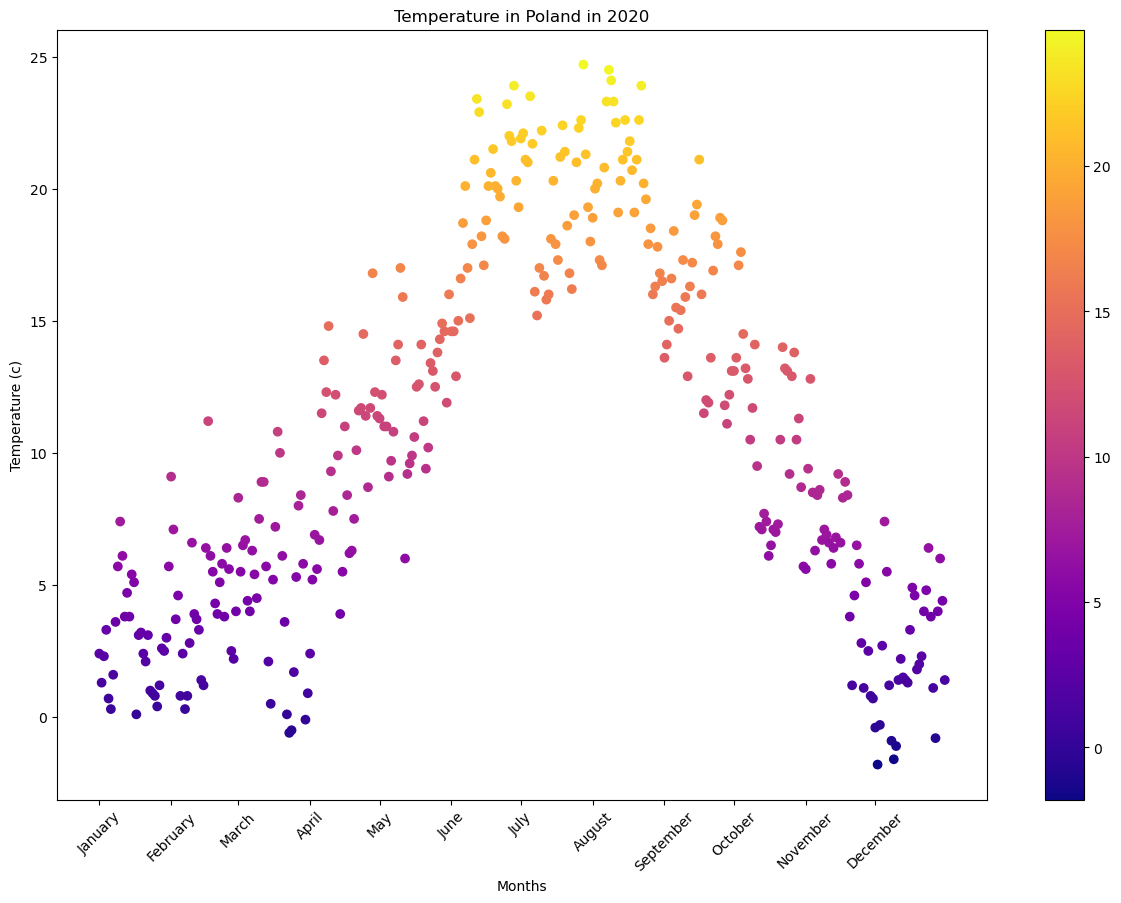

In [14]:
plt.figure(figsize=(15,10))
 
plt.scatter(df.index, df['Average daily temperature'],
            c=df['Average daily temperature'], cmap='plasma')
 
plt.xticks(months_change, months_names, rotation=45)
 
plt.ylabel('Temperature (c)')
plt.xlabel('Months')
 
plt.colorbar()  # method that displays a color map next to the plot (if used)
 
plt.title("Temperature in Poland in 2020")

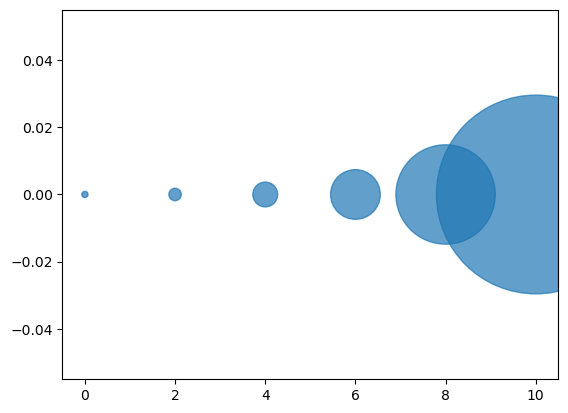

In [16]:
x = [0,2,4,6,8,10]
y = [0]*len(x)
s = [20*4**n for n in range(len(x))]
 
plt.scatter(x, y, s=s, alpha=0.7)
plt.show()